# Astrometric concordance: before vs after

Compares per-source astrometric offsets (band position vs VIS) **before** (raw WCS)
and **after** (NN matcher prediction) for all 9 target bands.

Uses the cached predictions from `infer_global_concordance.py --cache-predictions`,
which contains ~155k matched sources per band across 790 tiles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from scipy.ndimage import gaussian_filter

ROOT = Path('..').resolve()

# Path to the cached predictions from infer_global_concordance.py
CACHE_PATH = ROOT / 'checkpoints' / 'astro_v7_centernet_200tiles' / 'predictions_cache.npz'

RUBIN_BANDS = ['u', 'g', 'r', 'i', 'z', 'y']
NISP_BANDS  = ['Y', 'J', 'H']
ALL_TARGET_BANDS = RUBIN_BANDS + NISP_BANDS

# Band key mapping: how bands are stored in the cache npz
def _cache_key(bname):
    if bname in RUBIN_BANDS:
        return bname           # 'u', 'g', ...
    return f'nisp_{bname}'     # 'nisp_Y', 'nisp_J', 'nisp_H'

print(f'Cache: {CACHE_PATH}')
print(f'Exists: {CACHE_PATH.exists()}')

Cache: /home/shemmati/Work/Projects/JAISP/checkpoints/astro_v7_centernet_200tiles/predictions_cache.npz
Exists: True


## 1. Load cached predictions

In [2]:
cache = np.load(str(CACHE_PATH), allow_pickle=True)

# Load per-band raw offsets and NN predictions (both in arcsec -> convert to mas)
offsets_raw = {}
offsets_nn = {}

for bname in ALL_TARGET_BANDS:
    key = _cache_key(bname)
    ra_key = f'{key}_ra'
    if ra_key not in cache:
        print(f'  {bname}: not in cache')
        continue
    raw = cache[f'{key}_raw'] * 1000.0    # arcsec -> mas
    pred = cache[f'{key}_pred'] * 1000.0  # arcsec -> mas
    sigma = cache[f'{key}_sigma'] * 1000.0
    offsets_raw[bname] = raw
    offsets_nn[bname] = pred
    
    raw_rms = np.sqrt(np.mean(raw**2))
    pred_rms = np.sqrt(np.mean(pred**2))
    raw_med = np.median(np.hypot(raw[:, 0], raw[:, 1]))
    pred_med = np.median(np.hypot(pred[:, 0], pred[:, 1]))
    reduction = (1 - pred_med / raw_med) * 100
    print(f'  {bname:>5s}: {len(raw):>6d} sources | '
          f'Raw median={raw_med:5.1f} RMS={raw_rms:5.1f} | '
          f'NN median={pred_med:5.1f} RMS={pred_rms:5.1f} | '
          f'{reduction:+.0f}%')

      u: 151614 sources | Raw median=105.1 RMS=103.6 | NN median= 88.1 RMS= 88.3 | +16%
      g: 151612 sources | Raw median= 67.4 RMS= 91.5 | NN median= 58.9 RMS= 74.6 | +13%
      r: 151618 sources | Raw median= 57.6 RMS= 86.8 | NN median= 50.7 RMS= 72.1 | +12%
      i: 151618 sources | Raw median= 58.0 RMS= 83.9 | NN median= 51.9 RMS= 68.4 | +11%
      z: 151616 sources | Raw median= 69.3 RMS= 88.0 | NN median= 61.1 RMS= 72.1 | +12%
      y: 151627 sources | Raw median= 94.0 RMS= 97.8 | NN median= 74.6 RMS= 79.2 | +21%
      Y: 155709 sources | Raw median= 44.9 RMS= 39.0 | NN median=  4.4 RMS=  5.7 | +90%
      J: 155609 sources | Raw median= 44.1 RMS= 38.3 | NN median=  5.2 RMS=  6.4 | +88%
      H: 155260 sources | Raw median= 44.7 RMS= 38.9 | NN median=  5.8 RMS=  6.9 | +87%


## 2. Before vs After contour plot

Left: raw WCS offsets (band position - VIS position).  
Right: NN matcher residuals after concordance correction.  
Solid = Rubin, dashed = NISP.

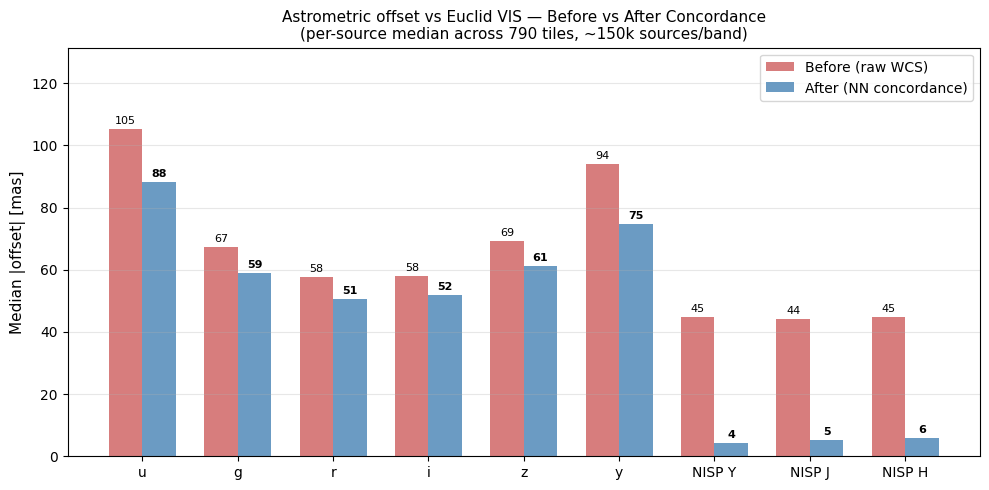

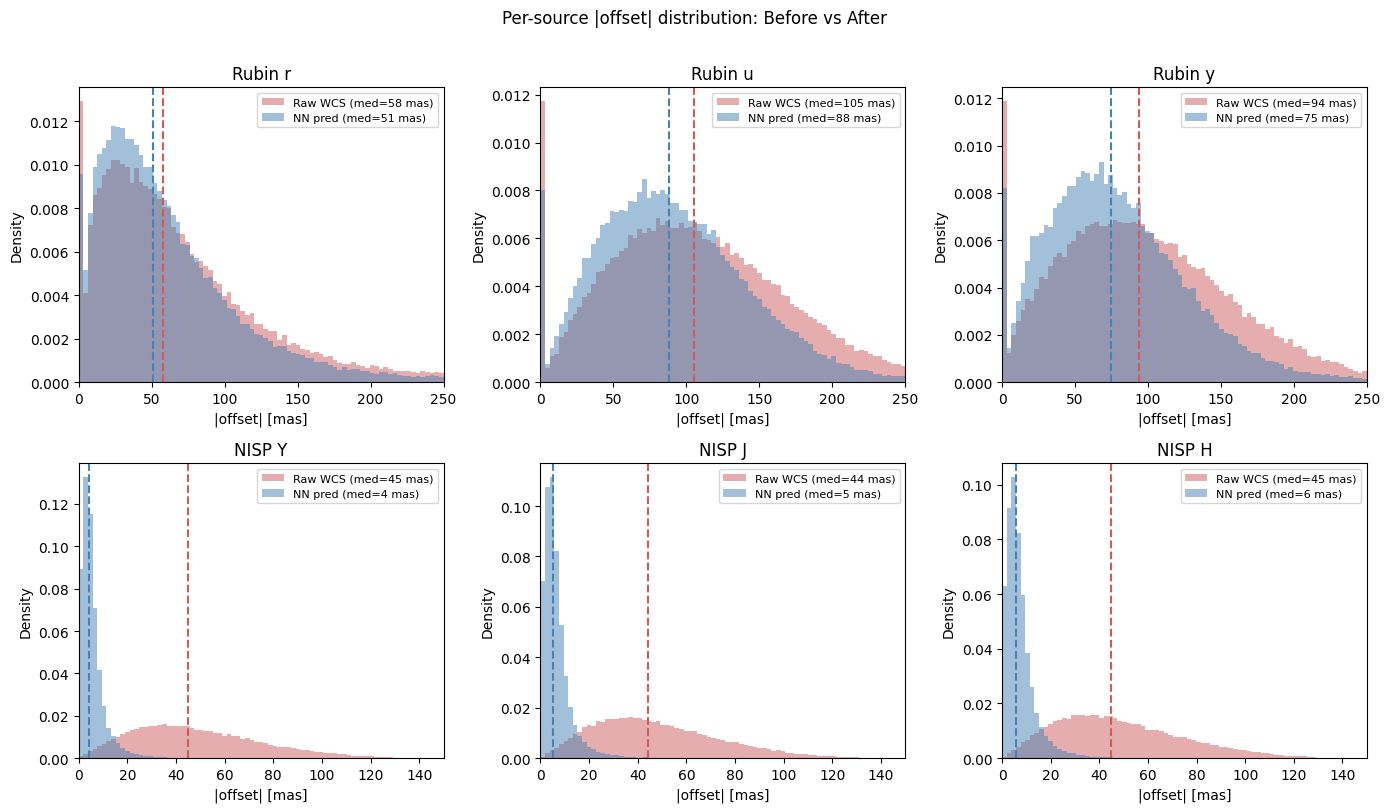

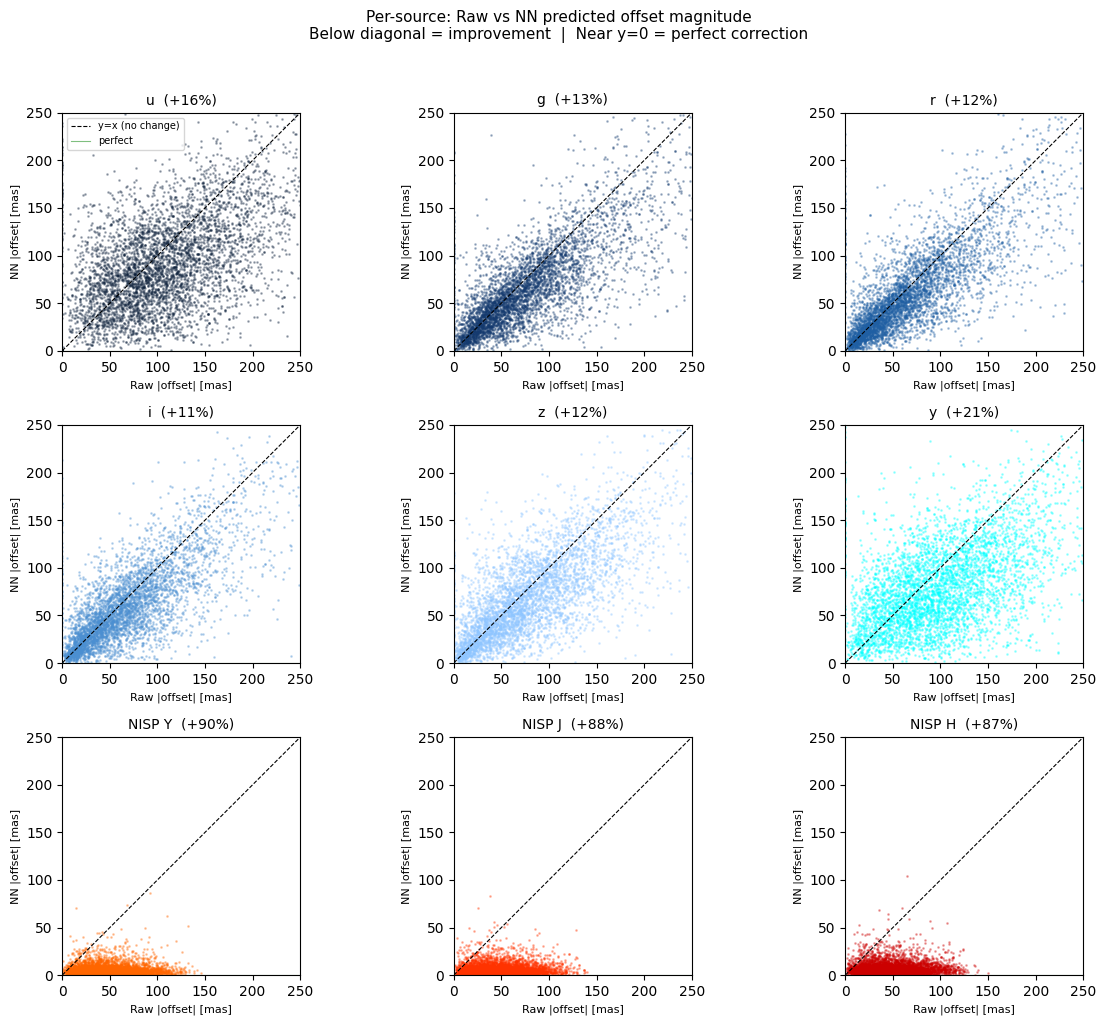

In [3]:
BAND_COLORS = {
    'u': '#0B1F3A', 'g': '#143A6F', 'r': '#1F5FA3',
    'i': '#4B8FD1', 'z': '#8FC6FF', 'y': '#00FFFF',
    'Y': '#FF6600', 'J': '#FF3300', 'H': '#CC0000',
}

# ---- Plot 1: Bar chart — median |offset| before vs after, per band ----
fig, ax = plt.subplots(figsize=(10, 5))

bands_present = [b for b in ALL_TARGET_BANDS if b in offsets_raw]
x = np.arange(len(bands_present))
width = 0.35

raw_med = [np.median(np.hypot(offsets_raw[b][:,0], offsets_raw[b][:,1])) for b in bands_present]
nn_med  = [np.median(np.hypot(offsets_nn[b][:,0], offsets_nn[b][:,1])) for b in bands_present]

bars1 = ax.bar(x - width/2, raw_med, width, label='Before (raw WCS)', color='indianred', alpha=0.8)
bars2 = ax.bar(x + width/2, nn_med, width, label='After (NN concordance)', color='steelblue', alpha=0.8)

for bar, val in zip(bars1, raw_med):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, nn_med):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

labels = [f'NISP {b}' if b in NISP_BANDS else b for b in bands_present]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Median |offset| [mas]', fontsize=11)
ax.set_title('Astrometric offset vs Euclid VIS — Before vs After Concordance\n(per-source median across 790 tiles, ~150k sources/band)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(raw_med) * 1.25)
plt.tight_layout()
plt.savefig('astrometry_bar_chart.png', dpi=200, bbox_inches='tight')
plt.show()


# ---- Plot 2: Histograms of |offset| for representative bands ----
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

hist_bands = ['r', 'u', 'y', 'Y', 'J', 'H']
for idx, band in enumerate(hist_bands):
    ax = axes[idx]
    raw_mag = np.hypot(offsets_raw[band][:,0], offsets_raw[band][:,1])
    nn_mag  = np.hypot(offsets_nn[band][:,0], offsets_nn[band][:,1])

    xlim = 250 if band in RUBIN_BANDS else 150
    bins = np.linspace(0, xlim, 80)
    ax.hist(raw_mag, bins=bins, alpha=0.5, color='indianred',
            label=f'Raw WCS (med={np.median(raw_mag):.0f} mas)', density=True)
    ax.hist(nn_mag, bins=bins, alpha=0.5, color='steelblue',
            label=f'NN pred (med={np.median(nn_mag):.0f} mas)', density=True)
    ax.axvline(np.median(raw_mag), color='indianred', ls='--', lw=1.5)
    ax.axvline(np.median(nn_mag), color='steelblue', ls='--', lw=1.5)
    ax.set_xlabel('|offset| [mas]')
    ax.set_ylabel('Density')
    prefix = 'NISP ' if band in NISP_BANDS else 'Rubin '
    ax.set_title(f'{prefix}{band}')
    ax.legend(fontsize=8)
    ax.set_xlim(0, xlim)

plt.suptitle('Per-source |offset| distribution: Before vs After', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('astrometry_histograms.png', dpi=200, bbox_inches='tight')
plt.show()


# ---- Plot 3: Raw vs NN scatter per band ----
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes_flat = axes.ravel()

for idx, band in enumerate(bands_present):
    ax = axes_flat[idx]
    raw_mag = np.hypot(offsets_raw[band][:,0], offsets_raw[band][:,1])
    nn_mag  = np.hypot(offsets_nn[band][:,0], offsets_nn[band][:,1])

    n = min(5000, len(raw_mag))
    rng = np.random.RandomState(42)
    sub = rng.choice(len(raw_mag), n, replace=False)

    ax.scatter(raw_mag[sub], nn_mag[sub], s=1, alpha=0.3, c=BAND_COLORS.get(band, 'gray'))
    ax.plot([0, 250], [0, 250], 'k--', lw=0.8, label='y=x (no change)')
    ax.plot([0, 250], [0, 0], 'g-', lw=0.8, alpha=0.5, label='perfect')
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 250)
    ax.set_aspect('equal')
    prefix = 'NISP ' if band in NISP_BANDS else ''
    reduction = (1 - np.median(nn_mag) / np.median(raw_mag)) * 100
    ax.set_title(f'{prefix}{band}  ({reduction:+.0f}%)', fontsize=10)
    ax.set_xlabel('Raw |offset| [mas]', fontsize=8)
    ax.set_ylabel('NN |offset| [mas]', fontsize=8)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Per-source: Raw vs NN predicted offset magnitude\n'
             'Below diagonal = improvement  |  Near y=0 = perfect correction',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('astrometry_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Decomposed statistics: systematic offset vs centroid noise

- **|systematic|** = `hypot(median(dRA), median(dDec))` — the bulk WCS misalignment that the concordance field removes  
- **med|offset|** = `median(hypot(dRA_i, dDec_i))` — typical per-source scatter (includes centroid noise)
- **MAD** = per-axis scatter — the irreducible centroid noise floor at each instrument's pixel scale

The concordance corrects the **systematic** part. The **MAD** stays roughly constant because it's centroid noise.

**NOTE**: Current results used `refine_radius=3` for Rubin centroids (1.4" box on 0.2"/px images), which inflated Rubin scatter by ~40 mas. This has been fixed to `refine_radius=1` (matching NISP). Retrain + re-infer to see the improvement.

In [ ]:
def _mad_sigma(x):
    return 1.4826 * np.median(np.abs(x - np.median(x)))

bands_present = [b for b in ALL_TARGET_BANDS if b in offsets_raw]

print(f"{'Band':<8} {'N':>7}   {'|sys|':>6} {'med|off|':>8} {'MAD_RA':>7} {'MAD_De':>7}   "
      f"{'|sys|':>6} {'med|off|':>8} {'MAD_RA':>7} {'MAD_De':>7}   {'sys red':>7}")
print(f"{'':8s} {'':7s}   {'':>6} {'':>8} {'':>7} {'':>7}   "
      f"{'':>6} {'':>8} {'':>7} {'':>7}   {'':>7}")
print(f"{'':8s} {'':7s}   {'--- Raw WCS ---':^30s}   {'--- NN Concordance ---':^30s}")
print('-' * 100)

for bname in bands_present:
    raw = offsets_raw[bname]
    pred = offsets_nn[bname]
    n = len(raw)
    
    raw_sys = np.hypot(np.median(raw[:,0]), np.median(raw[:,1]))
    nn_sys  = np.hypot(np.median(pred[:,0]), np.median(pred[:,1]))
    
    raw_med = np.median(np.hypot(raw[:,0], raw[:,1]))
    nn_med  = np.median(np.hypot(pred[:,0], pred[:,1]))
    
    raw_mad_ra  = _mad_sigma(raw[:,0])
    raw_mad_dec = _mad_sigma(raw[:,1])
    nn_mad_ra   = _mad_sigma(pred[:,0])
    nn_mad_dec  = _mad_sigma(pred[:,1])
    
    sys_red = (1 - nn_sys / max(raw_sys, 0.1)) * 100
    
    prefix = 'NISP_' if bname in NISP_BANDS else ''
    label = f'{prefix}{bname}'
    print(f'  {label:<7} {n:>6}   {raw_sys:>6.1f} {raw_med:>8.1f} {raw_mad_ra:>7.1f} {raw_mad_dec:>7.1f}'
          f'   {nn_sys:>6.1f} {nn_med:>8.1f} {nn_mad_ra:>7.1f} {nn_mad_dec:>7.1f}'
          f'   {sys_red:>+6.0f}%')

print()
print('Key insight: NISP had large systematic (~44 mas) which the NN removes → 90% improvement.')
print('Rubin systematic was already small (~6-40 mas). The large med|offset| for Rubin is')
print('centroid noise from refine_radius=3 on 0.2"/px images, not WCS error.')